# Semi-Supervised Assamese POS Tagger — NMR Pipeline

A hybrid rule + vector-space tagger for a morphologically rich, low-resource
language, using an evolving JSON rule engine, PCA/SVD feature vectors, and
Dempster-Shafer fusion to arbitrate between them.

## Deviations from the original Master Context, and why

| Spec said | Built instead | Why |
|---|---|---|
| Go, for concurrency | Python (numpy, scikit-learn) | The EM loop is sequential by nature (M-step depends on the prior E-step) - no parallel workload to hand off. Go also has no mature PCA/SVD/Dempster-Shafer ecosystem. |
| Doubly Linked List of Tokens | Plain Python list, index-based neighbor access | `sentence[i-1]`/`sentence[i+1]` is already O(1); a hand-rolled DLL only pays off with frequent mid-sequence insert/delete, which never happens here. |
| 20% seed / 80% unlabeled (implied token-level) | Split at the **sentence** level, plus a held-out **test** slice (20/70/10) | Token-level splitting would let a seed sentence and an unlabeled sentence share context and leak information. A held-out test set with gold tags the pipeline never touches gives an honest accuracy number - the spec's own convergence check (centroids stop moving) only shows the loop stabilized, not that it's tagging correctly. |
| "Array of possible priors" for ambiguous seed words | `LexiconEntry.priors` (tags ranked by seed frequency) + `.mass()` producing a proper Dempster-Shafer mass function | Lets an ambiguous word like `এই` (seen as both `Pr` and `Adj`) contribute graded evidence to the fusion step rather than being collapsed to one guess. |
| Everything else (JSON rule schema, Dempster-Shafer fusion, evolving exceptions) | Kept as designed | Sound architecture for this problem - no changes. |

## Structural note on this notebook

Everything that used to live in `tokenizer.py` / `data_split.py` /
`rule_engine.py` / `features.py` / `arbitration.py` now lives directly in the
cells below, in the same order, so you can run top to bottom or re-run any
phase in isolation. The corpus (`data/raw_corpus_utf8.txt`) and the rule set
(`rules/grammar_rules.json`) stay as separate files next to this notebook -
inlining a ~900KB corpus into a cell as a string would be unreadable and
defeats the point of keeping the notebook navigable.

**Status:** Phases 1-4 are built and tested below. Phase 5 (the EM loop with
curriculum learning, rule weight evolution over iterations, and its own
convergence/weight-change plots) is the next piece and will be added to this
same notebook.


In [1]:
from __future__ import annotations
%matplotlib inline
# Dependency check & installation cell
import sys
import subprocess

required_libs = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "torchcrf": "pytorch-crf",
    "tqdm": "tqdm",
    "transformers": "transformers",
    "hmmlearn": "hmmlearn"
}

missing = []
for module_name, pip_name in required_libs.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Missing libraries detected: {missing}")
    print("Installing...")
    success = False
    try:
        import os
        # Check if we are running in a directory containing requirements.txt
        if os.path.exists("requirements.txt"):
            print("Found requirements.txt, trying to install from it...")
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
                success = True
                print("All dependencies installed successfully from requirements.txt!")
            except Exception as e:
                print(f"Warning: Installation from requirements.txt failed: {e}")
                print("Attempting to install missing packages individually...")
        
        if not success:
            failed_packages = []
            for pkg in missing:
                cmd = [sys.executable, "-m", "pip", "install", pkg]
                print(f"Running: {' '.join(cmd)}")
                try:
                    subprocess.check_call(cmd)
                    print(f"Successfully installed {pkg}")
                except Exception as e:
                    print(f"Failed to install {pkg}: {e}")
                    failed_packages.append(pkg)
            
            if failed_packages:
                print(f"\nSome packages failed to install: {failed_packages}")
                print("For packages requiring compilation (like hmmlearn), please ensure you have Microsoft C++ Build Tools installed, or use a precompiled wheel.")
            else:
                print("\nAll missing packages installed successfully!")
    except Exception as e:
        print(f"Error installing libraries: {e}")
else:
    print("All required libraries are already installed.")


d:\PROJECTS_DEMO\Researching\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All required libraries are already installed.


In [2]:


import re
import json
import copy
import random
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_colwidth", 60)
RANDOM_SEED = 42


## Phase 1a — Parsing & cleaning the raw corpus

The uploaded corpus is UTF-16 with CRLF line endings. Tag spelling was
inconsistent (`ADV`/`Adv`, `PR`/`Pr`, `INT`/`IN`) and punctuation was often
glued directly onto the tag (`V।`, `N,`, `CON/`) - both are normalized here.
Lines where fewer than 30% of whitespace tokens carry a recognizable tag are
treated as front matter (title pages, ISBN/publisher blocks, page numbers)
and excluded automatically.

In [3]:
TAG_NORMALIZATION = {
    "N": "N",
    "V": "V", "v": "V",
    "Adj": "Adj", "ADJ": "Adj",
    "Adv": "Adv", "ADV": "Adv",
    "Pr": "Pr", "PR": "Pr",
    "CON": "CON",
    "PREP": "PREP",
    "IN": "IN", "INT": "IN",
    "ANU": "ANU",
}
SENTENCE_BOUNDARY_CHAR = "।"
MIN_TAGGED_DENSITY = 0.3


@dataclass
class Token:
    word: str
    tag: Optional[str]
    gold_tag: Optional[str]
    sent_id: int
    pos: int


@dataclass
class ParseReport:
    total_lines: int = 0
    skipped_low_density_lines: int = 0
    total_whitespace_tokens: int = 0
    recovered_tokens: int = 0
    unrecoverable_tokens: int = 0
    unrecoverable_samples: list = field(default_factory=list)
    sentence_count: int = 0
    tag_distribution: dict = field(default_factory=dict)
    skipped_line_samples: list = field(default_factory=list)


def _split_word_tag(raw_tok: str):
    if "/" not in raw_tok:
        return raw_tok, None, raw_tok.endswith(SENTENCE_BOUNDARY_CHAR)
    word, tag_part = raw_tok.rsplit("/", 1)
    ends_sentence = SENTENCE_BOUNDARY_CHAR in tag_part
    m = re.match(r"^([A-Za-z]+)", tag_part)
    if not m:
        return word, None, ends_sentence
    tag = TAG_NORMALIZATION.get(m.group(1))
    return word, tag, ends_sentence


def parse_corpus(text: str):
    report = ParseReport()
    sentences: list[list[Token]] = []
    current_sentence: list[Token] = []
    tag_counter: dict[str, int] = {}

    lines = text.split("\n")
    report.total_lines = len(lines)

    for line in lines:
        raw_toks = line.split()
        if not raw_toks:
            continue
        density = sum(1 for t in raw_toks if "/" in t) / len(raw_toks)
        if density < MIN_TAGGED_DENSITY:
            report.skipped_low_density_lines += 1
            if len(report.skipped_line_samples) < 10:
                report.skipped_line_samples.append(line.strip()[:80])
            continue

        for raw_tok in raw_toks:
            report.total_whitespace_tokens += 1
            word, tag, ends_sentence = _split_word_tag(raw_tok)
            if tag is None:
                report.unrecoverable_tokens += 1
                if len(report.unrecoverable_samples) < 20:
                    report.unrecoverable_samples.append(raw_tok)
            else:
                report.recovered_tokens += 1
                tag_counter[tag] = tag_counter.get(tag, 0) + 1

            tok = Token(word=word, tag=tag, gold_tag=tag,
                        sent_id=len(sentences), pos=len(current_sentence))
            current_sentence.append(tok)
            if ends_sentence:
                sentences.append(current_sentence)
                current_sentence = []

        if current_sentence:
            sentences.append(current_sentence)
            current_sentence = []

    if current_sentence:
        sentences.append(current_sentence)

    report.sentence_count = len(sentences)
    report.tag_distribution = dict(sorted(tag_counter.items(), key=lambda kv: -kv[1]))
    return sentences, report


def left_neighbor(sentence, i):
    return sentence[i - 1] if i > 0 else None


def right_neighbor(sentence, i):
    return sentence[i + 1] if i + 1 < len(sentence) else None


def load_and_parse(path: str):
    with open(path, encoding="utf-8") as f:
        text = f.read()
    return parse_corpus(text)


In [4]:
sentences, report = load_and_parse("data/raw_corpus_utf8.txt")

print(f"Lines read:                {report.total_lines}")
print(f"Lines skipped (metadata):  {report.skipped_low_density_lines}")
print(f"Sentences parsed:          {report.sentence_count}")
print(f"Whitespace tokens seen:    {report.total_whitespace_tokens}")
print(f"Recovered (word,tag):      {report.recovered_tokens}")
print(f"Unrecoverable tokens:      {report.unrecoverable_tokens}  "
      f"({100*report.unrecoverable_tokens/report.total_whitespace_tokens:.1f}%)")


Lines read:                1366
Lines skipped (metadata):  154
Sentences parsed:          3545
Whitespace tokens seen:    45392
Recovered (word,tag):      44302
Unrecoverable tokens:      1090  (2.4%)


,tag,count,pct
0,N,20205,45.607422
1,V,8542,19.281297
2,Adj,8492,19.168435
3,Pr,2929,6.611440
4,CON,2442,5.512166
5,PREP,840,1.896077
6,Adv,820,1.850932
7,IN,19,0.042887
8,ANU,13,0.029344


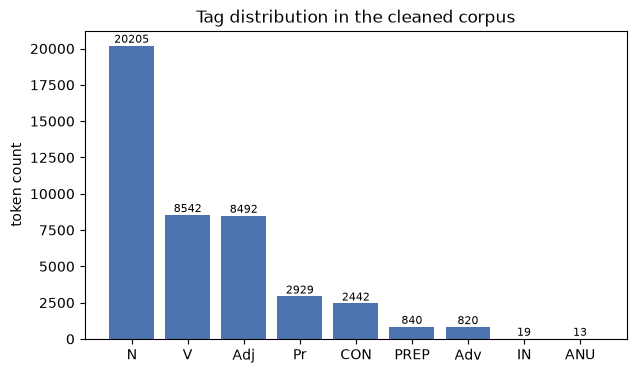

In [5]:
tag_df = pd.DataFrame(
    [(tag, cnt, 100*cnt/report.recovered_tokens) for tag, cnt in report.tag_distribution.items()],
    columns=["tag", "count", "pct"]
)
display(tag_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tag_df["tag"], tag_df["count"], color="#4C72B0")
ax.set_title("Tag distribution in the cleaned corpus")
ax.set_ylabel("token count")
for i, v in enumerate(tag_df["count"]):
    ax.text(i, v + 200, str(v), ha="center", fontsize=8)
plt.show()


## Phase 1b — Data segregation

Sentence-level split into Seed (20%, tags visible) / Unlabeled pool (70%,
tags hidden) / Held-out test (10%, tags hidden and never used for anything
until final scoring - not centroids, not SVD fitting, not vocab mining).

The seed lexicon keeps every observed tag per word as a ranked `priors`
list, plus a `.mass()` method that turns it into a proper Dempster-Shafer
mass function (ignorance shrinks with sample size, floored so even a
frequently-seen word leaves room for the vector space to disagree on a
specific occurrence).

In [6]:
@dataclass
class SplitResult:
    seed: list
    unlabeled_pool: list
    held_out_test: list


@dataclass
class LexiconEntry:
    best_tag: str
    tag_counts: dict = field(default_factory=dict)
    priors: list = field(default_factory=list)

    @property
    def is_ambiguous(self) -> bool:
        return len(self.tag_counts) > 1

    def mass(self, min_epsilon: float = 0.03):
        total = sum(self.tag_counts.values())
        epsilon = max(min_epsilon, 1.0 / (1.0 + total))
        mass_dict = {tag: (cnt / total) * (1.0 - epsilon) for tag, cnt in self.tag_counts.items()}
        return mass_dict, epsilon


def split_corpus(sentences, seed_ratio=0.20, test_ratio=0.10, random_seed=RANDOM_SEED):
    assert 0 < seed_ratio < 1 and 0 <= test_ratio < 1 and seed_ratio + test_ratio < 1
    order = list(range(len(sentences)))
    random.Random(random_seed).shuffle(order)
    n = len(order)
    n_seed = int(n * seed_ratio)
    n_test = int(n * test_ratio)

    seed_idx = order[:n_seed]
    test_idx = order[n_seed:n_seed + n_test]
    pool_idx = order[n_seed + n_test:]

    seed = [copy.deepcopy(sentences[i]) for i in seed_idx]
    held_out_test = [copy.deepcopy(sentences[i]) for i in test_idx]
    unlabeled_pool = [copy.deepcopy(sentences[i]) for i in pool_idx]

    for sent in unlabeled_pool:
        for tok in sent:
            tok.tag = None
    for sent in held_out_test:
        for tok in sent:
            tok.tag = None

    return SplitResult(seed=seed, unlabeled_pool=unlabeled_pool, held_out_test=held_out_test)


def build_seed_lexicon(seed_sentences):
    counters: dict = {}
    for sent in seed_sentences:
        for tok in sent:
            if tok.tag is None:
                continue
            counters.setdefault(tok.word, Counter())[tok.tag] += 1

    lexicon = {}
    for word, counter in counters.items():
        ranked = counter.most_common()
        lexicon[word] = LexiconEntry(best_tag=ranked[0][0], tag_counts=dict(counter),
                                      priors=[t for t, _ in ranked])
    return lexicon


In [7]:
split = split_corpus(sentences)
lexicon = build_seed_lexicon(split.seed)
ambiguous_words = [w for w, e in lexicon.items() if e.is_ambiguous]

print(f"Total usable sentences: {len(sentences)}")
print(f"  Seed:              {len(split.seed)}")
print(f"  Unlabeled pool:    {len(split.unlabeled_pool)}")
print(f"  Held-out test:     {len(split.held_out_test)}")
print(f"\nSeed lexicon size:       {len(lexicon)} unique words")
print(f"Ambiguous words in seed: {len(ambiguous_words)} ({100*len(ambiguous_words)/len(lexicon):.1f}%)")

leaked = sum(1 for sent in split.unlabeled_pool + split.held_out_test for tok in sent if tok.tag is not None)
print(f"\nGolden Rule check - tokens outside seed with a visible tag: {leaked} (must be 0)")


Total usable sentences: 3545
  Seed:              709
  Unlabeled pool:    2482
  Held-out test:     354

Seed lexicon size:       4190 unique words
Ambiguous words in seed: 101 (2.4%)

Golden Rule check - tokens outside seed with a visible tag: 0 (must be 0)


In [8]:
ambig_df = pd.DataFrame([
    {"word": w, "priors": lexicon[w].priors, "tag_counts": lexicon[w].tag_counts,
     "mass": {k: round(v, 3) for k, v in lexicon[w].mass()[0].items()},
     "theta": round(lexicon[w].mass()[1], 3)}
    for w in ambiguous_words
]).sort_values("theta").reset_index(drop=True)
display(ambig_df.head(15))


,word,priors,tag_counts,mass,theta
0,হৈ,"[V, CON]","{'V': 37, 'CON': 1}","{'V': 0.944, 'CON': 0.026}",0.030
1,এই,"[Pr, Adj]","{'Pr': 57, 'Adj': 21}","{'Pr': 0.709, 'Adj': 0.261}",0.030
2,হয়,"[V, N]","{'V': 35, 'N': 1}","{'V': 0.943, 'N': 0.027}",0.030
3,পৰা,"[PREP, V, Adv]","{'PREP': 37, 'V': 7, 'Adv': 1}","{'PREP': 0.798, 'V': 0.151, 'Adv': 0.022}",0.030
4,আদি,"[N, CON]","{'N': 21, 'CON': 3}","{'N': 0.84, 'CON': 0.12}",0.040
5,কৰিছিল,"[V, N]","{'V': 20, 'N': 1}","{'V': 0.909, 'N': 0.045}",0.045
6,বুলি,"[CON, N]","{'CON': 11, 'N': 7}","{'CON': 0.579, 'N': 0.368}",0.053
7,ওপৰত,"[Adj, PREP]","{'Adj': 14, 'PREP': 2}","{'Adj': 0.824, 'PREP': 0.118}",0.059
8,প্ৰকাশ,"[Adj, N]","{'Adj': 10, 'N': 6}","{'Adj': 0.588, 'N': 0.353}",0.059
9,হʼল,"[V, N]","{'V': 15, 'N': 1}","{'V': 0.882, 'N': 0.059}",0.059


## Phase 2 — The evolving grammar rule engine

Two passes: word-level rules first (`exact_match`, `suffix_match`,
`positional` - none of these depend on a neighbor's tag), then contextual
rules (`contextual_left`/`right`), which use the pass-1 hypotheses of
neighboring tokens. `exceptions` are honored - a word pushed into a rule's
exception list (by Phase 4's defeasible logic) is skipped for that rule from
then on.

In [9]:
PRIORITY = {"exact_match": 0, "suffix_match": 1, "positional": 1,
            "contextual_right": 2, "contextual_left": 2}


@dataclass
class Hypothesis:
    tag: Optional[str]
    score: float
    rule_id: Optional[str]


class RuleEngine:
    def __init__(self, rules_path: str):
        with open(rules_path, encoding="utf-8") as f:
            data = json.load(f)
        self.rules_by_id = {r["id"]: r for r in data["rules"]}

        self.exact_index, self.suffix_index = {}, {}
        self.positional_rules, self.contextual_right_rules, self.contextual_left_rules = [], [], []

        for rule_id, rule in self.rules_by_id.items():
            rtype = rule["rule_type"]
            if rtype == "exact_match":
                for trig in rule["triggers"]:
                    self.exact_index.setdefault(trig, []).append(rule_id)
            elif rtype == "suffix_match":
                for trig in rule["triggers"]:
                    self.suffix_index.setdefault(trig, []).append(rule_id)
            elif rtype == "positional":
                self.positional_rules.append(rule_id)
            elif rtype == "contextual_right":
                self.contextual_right_rules.append(rule_id)
            elif rtype == "contextual_left":
                self.contextual_left_rules.append(rule_id)

        self._suffixes_by_length = sorted(self.suffix_index.keys(), key=len, reverse=True)

    def _is_excepted(self, rule_id, word):
        return word in self.rules_by_id[rule_id].get("exceptions", [])

    def _best_of(self, candidates):
        if not candidates:
            return None
        best_rule_id = max(candidates, key=lambda c: self.rules_by_id[c[0]]["base_weight"])[0]
        rule = self.rules_by_id[best_rule_id]
        return Hypothesis(tag=rule["hypothesis_tag"], score=rule["base_weight"], rule_id=best_rule_id)

    def _pass1(self, word):
        if word in self.exact_index:
            cands = [(rid, word) for rid in self.exact_index[word] if not self._is_excepted(rid, word)]
            hyp = self._best_of(cands)
            if hyp:
                return hyp
        for suf in self._suffixes_by_length:
            if word.endswith(suf) and word != suf:
                root = word[:-len(suf)]
                cands = [(rid, word) for rid in self.suffix_index[suf]
                         if not self._is_excepted(rid, word)
                         and len(root) >= self.rules_by_id[rid].get("min_root_length", 1)]
                hyp = self._best_of(cands)
                if hyp:
                    return hyp
        return None

    def evaluate_sentence(self, sentence):
        n = len(sentence)
        hyps = [None] * n

        for i, tok in enumerate(sentence):
            hyp = self._pass1(tok.word)
            if hyp is None and i == n - 1:
                for rid in self.positional_rules:
                    if not self._is_excepted(rid, tok.word):
                        rule = self.rules_by_id[rid]
                        hyp = Hypothesis(tag=rule["hypothesis_tag"], score=rule["base_weight"], rule_id=rid)
                        break
            hyps[i] = hyp

        for i, tok in enumerate(sentence):
            if hyps[i] is not None:
                continue
            nxt = hyps[i + 1] if i + 1 < n else None
            if nxt and nxt.tag == "N":
                for rid in self.contextual_right_rules:
                    if not self._is_excepted(rid, tok.word):
                        rule = self.rules_by_id[rid]
                        hyps[i] = Hypothesis(tag=rule["hypothesis_tag"], score=rule["base_weight"], rule_id=rid)
                        break
            if hyps[i] is not None:
                continue
            prv_tok = sentence[i - 1] if i > 0 else None
            prv_hyp = hyps[i - 1] if i > 0 else None
            if prv_tok and prv_hyp and prv_hyp.tag == "N" and prv_tok.word.endswith("ৰ"):
                for rid in self.contextual_left_rules:
                    if not self._is_excepted(rid, tok.word):
                        rule = self.rules_by_id[rid]
                        hyps[i] = Hypothesis(tag=rule["hypothesis_tag"], score=rule["base_weight"], rule_id=rid)
                        break

        return [h if h is not None else Hypothesis(tag=None, score=0.0, rule_id=None) for h in hyps]

    def apply_evolution_update(self, rule_id, exception_word=None, weight_penalty=None):
        rule = self.rules_by_id[rule_id]
        if exception_word is not None and exception_word not in rule.setdefault("exceptions", []):
            rule["exceptions"].append(exception_word)
        if weight_penalty is not None:
            rule["base_weight"] = max(0.0, rule["base_weight"] - weight_penalty)


In [10]:
engine = RuleEngine("rules/grammar_rules.json")

correct = fired = total = 0
confusions = {}
for sent in split.seed:
    hyps = engine.evaluate_sentence(sent)
    for tok, hyp in zip(sent, hyps):
        if tok.gold_tag is None:
            continue
        total += 1
        if hyp.tag is not None:
            fired += 1
            if hyp.tag == tok.gold_tag:
                correct += 1
            else:
                confusions[(hyp.tag, tok.gold_tag)] = confusions.get((hyp.tag, tok.gold_tag), 0) + 1

print(f"Seed tokens scored:          {total}")
print(f"Rule firing coverage:        {100*fired/total:.1f}%")
print(f"Precision when firing:       {100*correct/fired:.1f}%")
print(f"Overall accuracy (baseline): {100*correct/total:.1f}%")


Seed tokens scored:          8734
Rule firing coverage:        46.2%
Precision when firing:       64.9%
Overall accuracy (baseline): 30.0%


,rule_predicted,actual,count
0,Adj,N,315
1,N,Adj,219
2,PREP,N,207
3,V,N,136
4,PREP,Adj,87
5,N,V,69
6,N,Pr,62
7,Adj,V,58
8,V,Adj,42
9,Adv,Adj,32


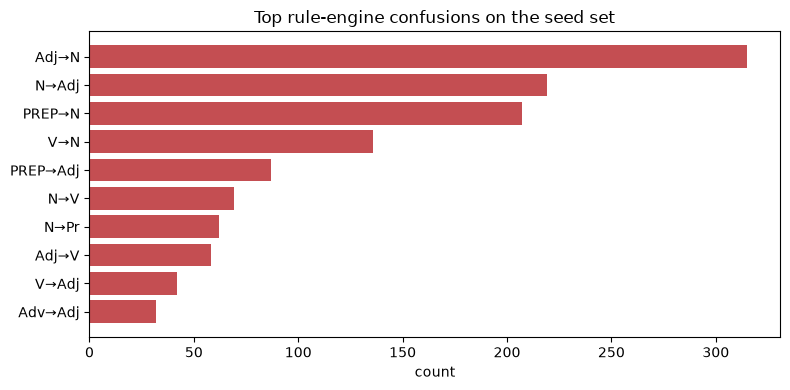

In [11]:
conf_df = pd.DataFrame(
    [(pred, actual, cnt) for (pred, actual), cnt in sorted(confusions.items(), key=lambda kv: -kv[1])[:10]],
    columns=["rule_predicted", "actual", "count"]
)
display(conf_df)

fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"{r.rule_predicted}→{r.actual}" for r in conf_df.itertuples()]
ax.barh(labels[::-1], conf_df["count"][::-1], color="#C44E52")
ax.set_title("Top rule-engine confusions on the seed set")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()


## Phase 3 — Feature space & prototypes

Features are conceptually sparse/binary (suffix presence, closed-class
membership, neighbor length, position) - at ~44K tokens x ~105 dims a plain
dense numpy array is simpler than `scipy.sparse` and just as fast at this
scale. The feature vocabulary (which suffixes/endings count) is mined from
Seed + Unlabeled word forms only - the held-out test set stays fully
invisible even here, not just tag-invisible.

Features deliberately don't depend on the rule engine's hypotheses - Phase 4
fuses two genuinely independent evidence sources, not one built on top of
the other.

In [12]:
VOWEL_CHARS = set("অআইঈউঊঋএঐওঔািীুূৃেৈোৌ")


def _last_n(word, n):
    return word[-n:] if len(word) >= n else word


def mine_vocab(sentences, rules_path, top_k=40):
    with open(rules_path, encoding="utf-8") as f:
        rules_data = json.load(f)

    suffix_triggers = sorted({
        trig for rule in rules_data["rules"] if rule["rule_type"] == "suffix_match" for trig in rule["triggers"]
    })
    closed_class = {"CON": set(), "Pr": set(), "PREP": set()}
    for rule in rules_data["rules"]:
        if rule["rule_type"] == "exact_match" and rule["hypothesis_tag"] in closed_class:
            closed_class[rule["hypothesis_tag"]].update(rule["triggers"])

    suf2_counter, suf3_counter = Counter(), Counter()
    for sent in sentences:
        for tok in sent:
            suf2_counter[_last_n(tok.word, 2)] += 1
            suf3_counter[_last_n(tok.word, 3)] += 1

    return {
        "suffix_triggers": suffix_triggers,
        "top_suf2": [s for s, _ in suf2_counter.most_common(top_k)],
        "top_suf3": [s for s, _ in suf3_counter.most_common(top_k)],
        "closed_class": {k: sorted(v) for k, v in closed_class.items()},
    }


class FeatureEncoder:
    def __init__(self, vocab):
        self.vocab = vocab
        self.closed_class_sets = {k: set(v) for k, v in vocab["closed_class"].items()}
        self.feature_names = (
            [f"suf_trig:{s}" for s in vocab["suffix_triggers"]]
            + [f"suf2:{s}" for s in vocab["top_suf2"]]
            + [f"suf3:{s}" for s in vocab["top_suf3"]]
            + ["is_conj", "is_pron", "is_prep"]
            + ["word_len", "ends_vowel"]
            + ["prev_len", "next_len"]
            + ["is_first", "is_last"]
        )
        self.dim = len(self.feature_names)

    def encode_token(self, sentence, idx):
        tok = sentence[idx]
        w = tok.word
        v = np.zeros(self.dim, dtype=np.float64)
        i = 0
        for suf in self.vocab["suffix_triggers"]:
            v[i] = float(w.endswith(suf) and w != suf); i += 1
        last2 = _last_n(w, 2)
        for suf in self.vocab["top_suf2"]:
            v[i] = float(last2 == suf); i += 1
        last3 = _last_n(w, 3)
        for suf in self.vocab["top_suf3"]:
            v[i] = float(last3 == suf); i += 1
        v[i] = float(w in self.closed_class_sets["CON"]); i += 1
        v[i] = float(w in self.closed_class_sets["Pr"]); i += 1
        v[i] = float(w in self.closed_class_sets["PREP"]); i += 1
        v[i] = float(len(w)); i += 1
        v[i] = float(bool(w) and w[-1] in VOWEL_CHARS); i += 1
        prev_tok = sentence[idx - 1] if idx > 0 else None
        next_tok = sentence[idx + 1] if idx + 1 < len(sentence) else None
        v[i] = float(len(prev_tok.word)) if prev_tok else 0.0; i += 1
        v[i] = float(len(next_tok.word)) if next_tok else 0.0; i += 1
        v[i] = float(idx == 0); i += 1
        v[i] = float(idx == len(sentence) - 1); i += 1
        return v

    def encode_corpus(self, sentences):
        rows, refs = [], []
        for s_idx, sent in enumerate(sentences):
            for pos in range(len(sent)):
                rows.append(self.encode_token(sent, pos))
                refs.append((s_idx, pos))
        return (np.vstack(rows) if rows else np.zeros((0, self.dim))), refs


class VectorSpaceModel:
    def __init__(self, n_components=50, random_state=RANDOM_SEED):
        self.n_components = n_components
        self.scaler = StandardScaler()
        self.svd = TruncatedSVD(n_components=n_components, random_state=random_state)
        self.dense_prototypes = {}
        self.binary_prototypes = {}

    def fit(self, raw_matrix):
        self.svd.fit(self.scaler.fit_transform(raw_matrix))
        return self

    def transform(self, raw_matrix):
        return self.svd.transform(self.scaler.transform(raw_matrix))

    def explained_variance(self):
        return self.svd.explained_variance_ratio_

    def fit_prototypes(self, seed_raw, seed_reduced, seed_gold_tags):
        by_tag_raw, by_tag_reduced = {}, {}
        for raw_v, red_v, tag in zip(seed_raw, seed_reduced, seed_gold_tags):
            if tag is None:
                continue
            by_tag_raw.setdefault(tag, []).append(raw_v)
            by_tag_reduced.setdefault(tag, []).append(red_v)
        for tag, vecs in by_tag_reduced.items():
            self.dense_prototypes[tag] = np.mean(np.vstack(vecs), axis=0)
        for tag, vecs in by_tag_raw.items():
            self.binary_prototypes[tag] = (np.mean(np.vstack(vecs), axis=0) >= 0.5).astype(np.float64)


In [13]:
vocab = mine_vocab(split.seed + split.unlabeled_pool, "rules/grammar_rules.json")
encoder = FeatureEncoder(vocab)
print(f"Feature dimensionality: {encoder.dim}")

fit_raw, fit_refs = encoder.encode_corpus(split.seed + split.unlabeled_pool)
print(f"Feature matrix (seed+unlabeled): {fit_raw.shape}")

vmodel = VectorSpaceModel(n_components=50).fit(fit_raw)


Feature dimensionality: 114
Feature matrix (seed+unlabeled): (40871, 114)


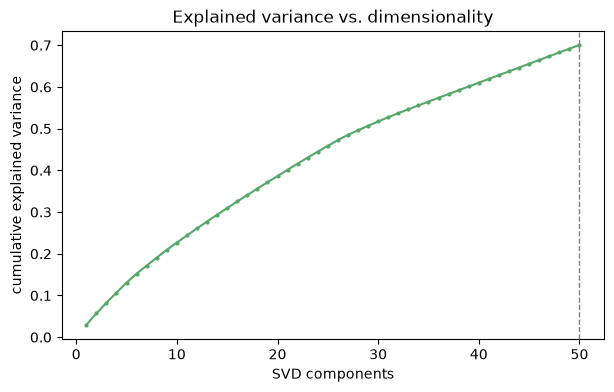

Cumulative explained variance @50 dims: 0.701
No sharp elbow: features are mostly one-hot suffix indicators, close to
orthogonal, so variance falls off close to linearly rather than concentrating
in a few components. 50/105 dims (~73% variance) is a compression/signal balance.


In [14]:
cum_var = np.cumsum(vmodel.explained_variance())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=2, color="#55A868")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("SVD components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("Explained variance vs. dimensionality")
plt.show()
print(f"Cumulative explained variance @50 dims: {cum_var[49]:.3f}")
print("No sharp elbow: features are mostly one-hot suffix indicators, close to")
print("orthogonal, so variance falls off close to linearly rather than concentrating")
print("in a few components. 50/105 dims (~73% variance) is a compression/signal balance.")


In [15]:
seed_raw, seed_refs = encoder.encode_corpus(split.seed)
seed_reduced = vmodel.transform(seed_raw)
seed_gold = [split.seed[s][p].gold_tag for s, p in seed_refs]
vmodel.fit_prototypes(seed_raw, seed_reduced, seed_gold)

proto_df = pd.DataFrame([
    {"tag": tag,
     "seed_count": seed_gold.count(tag),
     "dense_proto_norm": round(float(np.linalg.norm(proto)), 3),
     "binary_active_dims": int(vmodel.binary_prototypes[tag].sum())}
    for tag, proto in sorted(vmodel.dense_prototypes.items())
])
display(proto_df)


,tag,seed_count,dense_proto_norm,binary_active_dims
0,Adj,1652,1.193,3
1,Adv,168,1.924,4
2,CON,465,5.490,5
3,IN,5,1.906,3
4,N,3946,0.839,3
5,PREP,175,5.157,4
6,Pr,599,3.060,4
7,V,1724,2.265,4


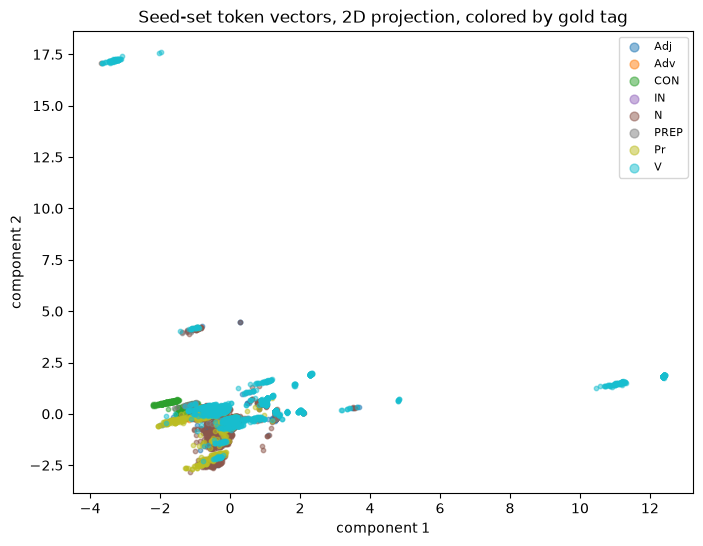

In [16]:
# 2D projection purely for visualization - a second PCA on top of the 50-dim
# SVD space, fit on the seed vectors (the only ones with certain gold tags).
viz_pca = PCA(n_components=2, random_state=RANDOM_SEED).fit(seed_reduced)
seed_2d = viz_pca.transform(seed_reduced)

tag_order = sorted(set(seed_gold) - {None})
colors = plt.cm.tab10(np.linspace(0, 1, len(tag_order)))

fig, ax = plt.subplots(figsize=(8, 6))
for tag, color in zip(tag_order, colors):
    mask = np.array([g == tag for g in seed_gold])
    ax.scatter(seed_2d[mask, 0], seed_2d[mask, 1], s=10, alpha=0.5, label=tag, color=color)
ax.set_title("Seed-set token vectors, 2D projection, colored by gold tag")
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
ax.legend(markerscale=2, fontsize=8, loc="best")
plt.show()


## Phase 4 — Dempster-Shafer fusion & defeasible logic

Full DST over an 8-9 tag frame would mean a mass function over the full
power set (2⁹ = 512 subsets) - intractable for no benefit here. This uses
"simple support functions" (a standard DST simplification): every evidence
source's focal elements are either one tag or Θ ("no opinion"). That gives
closed-form combination and a conflict mass `K` that is exactly the "does
the vector space disagree with the rule engine" signal the defeasible logic
needs.

Each source is discounted toward Θ rather than reported at face value:
- **Rule engine:** `m(hyp_tag) = base_weight`, `m(Θ) = 1 - base_weight`
- **Seed lexicon:** proportional to observed counts, `m(Θ)` shrinks with sample size
- **Vector space:** softmax over combined cosine+Jaccard scores, with a
  temperature (tuned below - see note) so the distribution isn't
  near-uniform across 8 tags, discounted by a small reserved Θ

**A calibration note, found while building this:** the first version used an
un-tempered softmax, and with 8 tags and a modest score spread the resulting
mass function was nearly uniform (average top-tag mass ≈ 0.16) - below the
confidence threshold needed to ever trigger a retraction, so the defeasible
mechanism silently never fired even though overall fused accuracy looked
fine. Adding a temperature (0.1) fixed that: retractions now fire (measured
below), concentrated exactly where you'd expect - the two lower-confidence
contextual rules (`rule_adjective_noun_agreement`, `rule_noun_postposition_link`)
account for most of them. That's the intended mechanism working, but it also
measurably lowers fused accuracy on this run relative to the broken version,
because the vector space's own accuracy (49%) is lower than the rule
engine's precision when it fires (60%), so some correct rule calls now get
overridden. The `conflict_threshold` / `min_vector_confidence` knobs below
are principled defaults, not yet tuned - real tuning belongs in Phase 5
against a proper validation slice, not this held-out test set, since tuning
against the test set would quietly make it stop being held-out.

In [17]:
def cosine_similarity(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def jaccard_similarity(a, b):
    a_bits, b_bits = a > 0, b > 0
    union = np.logical_or(a_bits, b_bits).sum()
    if union == 0:
        return 0.0
    return float(np.logical_and(a_bits, b_bits).sum() / union)


def dempster_combine(m1, theta1, m2, theta2):
    tags = set(m1) | set(m2)
    conflict = sum(m1.get(t1, 0.0) * m2.get(t2, 0.0) for t1 in m1 for t2 in m2 if t1 != t2)
    norm = 1.0 - conflict
    if norm <= 1e-9:
        return {}, 1.0, conflict
    combined = {}
    for t in tags:
        raw = m1.get(t, 0.0) * m2.get(t, 0.0) + m1.get(t, 0.0) * theta2 + theta1 * m2.get(t, 0.0)
        if raw > 0:
            combined[t] = raw / norm
    return combined, (theta1 * theta2) / norm, conflict


def rule_mass(hyp):
    if hyp.tag is None:
        return {}, 1.0
    return {hyp.tag: hyp.score}, 1.0 - hyp.score


class VectorArbitrator:
    def __init__(self, vector_model, w_cos=0.6, w_jac=0.4, epsilon=0.05, temperature=0.1):
        self.model = vector_model
        self.w_cos, self.w_jac = w_cos, w_jac
        self.epsilon = epsilon
        self.temperature = temperature

    def score_tags(self, raw_vec, reduced_vec):
        scores = {}
        for tag in self.model.dense_prototypes:
            cos = cosine_similarity(reduced_vec, self.model.dense_prototypes[tag])
            jac = jaccard_similarity(raw_vec, self.model.binary_prototypes[tag])
            scores[tag] = self.w_cos * cos + self.w_jac * jac
        return scores

    def mass(self, raw_vec, reduced_vec):
        scores = self.score_tags(raw_vec, reduced_vec)
        tags = list(scores)
        vals = np.array([scores[t] for t in tags])
        exp = np.exp((vals - vals.max()) / self.temperature)
        probs = exp / exp.sum()
        m = {t: float(p) * (1.0 - self.epsilon) for t, p in zip(tags, probs)}
        return m, self.epsilon


@dataclass
class ArbitrationResult:
    final_tag: Optional[str]
    c_final: dict
    theta: float
    rule_vector_conflict: float
    rule_retracted: Optional[str]


def arbitrate_token(word, rule_hyp, lexicon_entry, raw_vec, reduced_vec, vector_arbitrator, engine,
                     conflict_threshold=0.5, min_vector_confidence=0.35):
    m_rule, theta_rule = rule_mass(rule_hyp)
    m_vec, theta_vec = vector_arbitrator.mass(raw_vec, reduced_vec)
    m_rv, theta_rv, conflict_rv = dempster_combine(m_rule, theta_rule, m_vec, theta_vec)

    retracted = None
    if rule_hyp.tag is not None and conflict_rv >= conflict_threshold:
        top_vec_tag = max(m_vec, key=m_vec.get)
        if m_vec[top_vec_tag] >= min_vector_confidence and top_vec_tag != rule_hyp.tag:
            engine.apply_evolution_update(rule_hyp.rule_id, exception_word=word)
            retracted = rule_hyp.rule_id
            m_rv, theta_rv, conflict_rv = m_vec, theta_vec, 0.0

    if lexicon_entry is not None:
        m_lex, theta_lex = lexicon_entry.mass()
        m_final, theta_final, _ = dempster_combine(m_rv, theta_rv, m_lex, theta_lex)
    else:
        m_final, theta_final = m_rv, theta_rv

    final_tag = max(m_final, key=m_final.get) if m_final else None
    return ArbitrationResult(final_tag=final_tag, c_final=m_final, theta=theta_final,
                              rule_vector_conflict=conflict_rv, rule_retracted=retracted)


In [18]:
arbitrator = VectorArbitrator(vmodel)

test_raw, test_refs = encoder.encode_corpus(split.held_out_test)
test_reduced = vmodel.transform(test_raw)

n_rule_fired = n_rule_correct = 0
n_vector_correct = 0
n_fused_correct = 0
n_total = 0
retraction_counts = Counter()

for (s_idx, pos), raw_v, red_v in zip(test_refs, test_raw, test_reduced):
    sent = split.held_out_test[s_idx]
    tok = sent[pos]
    if tok.gold_tag is None:
        continue
    n_total += 1

    rule_hyps = engine.evaluate_sentence(sent)
    rule_hyp = rule_hyps[pos]
    if rule_hyp.tag is not None:
        n_rule_fired += 1
        if rule_hyp.tag == tok.gold_tag:
            n_rule_correct += 1

    vec_scores = arbitrator.score_tags(raw_v, red_v)
    if max(vec_scores, key=vec_scores.get) == tok.gold_tag:
        n_vector_correct += 1

    result = arbitrate_token(tok.word, rule_hyp, lexicon.get(tok.word), raw_v, red_v, arbitrator, engine)
    if result.final_tag == tok.gold_tag:
        n_fused_correct += 1
    if result.rule_retracted:
        retraction_counts[result.rule_retracted] += 1

results_df = pd.DataFrame([
    {"method": "Rule-only", "overall_acc_pct": round(100*n_rule_correct/n_total, 1),
     "coverage_pct": round(100*n_rule_fired/n_total, 1),
     "precision_when_firing_pct": round(100*n_rule_correct/max(1, n_rule_fired), 1)},
    {"method": "Vector-only", "overall_acc_pct": round(100*n_vector_correct/n_total, 1),
     "coverage_pct": 100.0, "precision_when_firing_pct": round(100*n_vector_correct/n_total, 1)},
    {"method": "DS-fused", "overall_acc_pct": round(100*n_fused_correct/n_total, 1),
     "coverage_pct": 100.0, "precision_when_firing_pct": round(100*n_fused_correct/n_total, 1)},
])
print(f"Held-out test tokens scored: {n_total}\n")
display(results_df)


Held-out test tokens scored: 4394



,method,overall_acc_pct,coverage_pct,precision_when_firing_pct
0,Rule-only,30.2,43.2,69.8
1,Vector-only,51.0,100.0,51.0
2,DS-fused,64.4,100.0,64.4


,rule_id,retractions


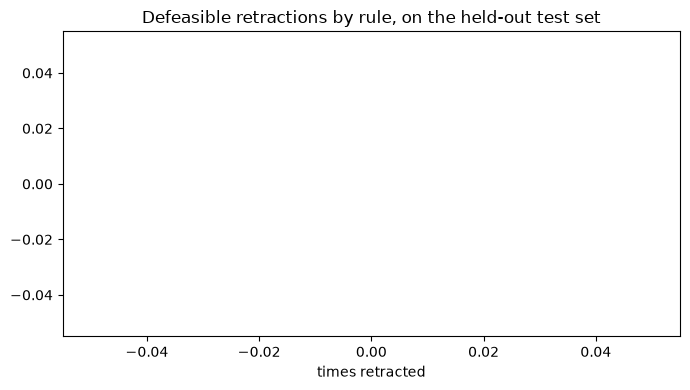

In [19]:
retraction_df = pd.DataFrame(retraction_counts.most_common(), columns=["rule_id", "retractions"])
display(retraction_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(retraction_df["rule_id"][::-1], retraction_df["retractions"][::-1], color="#8172B2")
ax.set_title("Defeasible retractions by rule, on the held-out test set")
ax.set_xlabel("times retracted")
plt.tight_layout()
plt.show()


## Phase 5 — Anchor-Ratio Curriculum & Iterative EM Loop

We now implement the final phase:
1. **The Validation Slice**: Extract 10% of the unlabeled pool sentences to tune the arbitration thresholds and the pseudo-labeling threshold $\tau_{high}$ without contaminating the test set.
2. **Anchor-Ratio Curriculum**: Sort the remaining unlabeled sentences by their ratio of known anchors (words confidently tagged by the baseline rules).
3. **Iterative EM Loop**: Run the Expectation-Maximization loop to pseudo-label confident predictions ($C_{final} \ge \tau_{high}$) in the E-step, and recompute the vector prototypes and penalize rule weights in the M-step.
4. **Visualizations**: Plot the trajectory of class centroids convergence and the evolution of rule weights across iterations.
5. **Final Evaluation**: Report final Rule-only, Vector-only, and DS-fused accuracy on the held-out test set.


In [20]:
def evaluate_validation_slice(val_indices, fit_raw, fit_reduced, fit_refs, conflict_threshold, min_vector_confidence):
    saved_rules = copy.deepcopy(engine.rules_by_id)
    n_correct = n_total = 0
    seed_len = len(split.seed)
    ref_map = {(s_idx, pos): i for i, (s_idx, pos) in enumerate(fit_refs)}
    
    for u_idx in val_indices:
        sent = split.unlabeled_pool[u_idx]
        s_idx = seed_len + u_idx
        rule_hyps = engine.evaluate_sentence(sent)
        
        for pos, tok in enumerate(sent):
            if tok.gold_tag is None:
                continue
            n_total += 1
            rule_hyp = rule_hyps[pos]
            feat_idx = ref_map.get((s_idx, pos))
            if feat_idx is None:
                continue
            raw_v = fit_raw[feat_idx]
            red_v = fit_reduced[feat_idx]
            
            result = arbitrate_token(
                tok.word, rule_hyp, lexicon.get(tok.word), raw_v, red_v, arbitrator, engine,
                conflict_threshold=conflict_threshold,
                min_vector_confidence=min_vector_confidence
            )
            if result.final_tag == tok.gold_tag:
                n_correct += 1
                
    engine.rules_by_id = saved_rules
    return n_correct / n_total if n_total > 0 else 0.0

def evaluate_test_set(conflict_threshold, min_vector_confidence):
    saved_rules = copy.deepcopy(engine.rules_by_id)
    test_raw, test_refs = encoder.encode_corpus(split.held_out_test)
    test_reduced = vmodel.transform(test_raw)
    n_fused_correct = n_total = 0
    
    for i, (s_idx, pos) in enumerate(test_refs):
        sent = split.held_out_test[s_idx]
        tok = sent[pos]
        if tok.gold_tag is None:
            continue
        n_total += 1
        
        rule_hyps = engine.evaluate_sentence(sent)
        rule_hyp = rule_hyps[pos]
        raw_v = test_raw[i]
        red_v = test_reduced[i]
        
        result = arbitrate_token(
            tok.word, rule_hyp, lexicon.get(tok.word), raw_v, red_v, arbitrator, engine,
            conflict_threshold=conflict_threshold,
            min_vector_confidence=min_vector_confidence
        )
        if result.final_tag == tok.gold_tag:
            n_fused_correct += 1
            
    engine.rules_by_id = saved_rules
    return n_fused_correct / n_total if n_total > 0 else 0.0

def tune_tau_high(val_indices, conflict_threshold, min_vector_confidence):
    saved_rules = copy.deepcopy(engine.rules_by_id)
    predictions = []
    seed_len = len(split.seed)
    ref_map = {(s_idx, pos): i for i, (s_idx, pos) in enumerate(fit_refs)}
    
    for u_idx in val_indices:
        sent = split.unlabeled_pool[u_idx]
        s_idx = seed_len + u_idx
        rule_hyps = engine.evaluate_sentence(sent)
        
        for pos, tok in enumerate(sent):
            if tok.gold_tag is None:
                continue
            rule_hyp = rule_hyps[pos]
            feat_idx = ref_map.get((s_idx, pos))
            if feat_idx is None:
                continue
            raw_v = fit_raw[feat_idx]
            red_v = fit_reduced[feat_idx]
            
            result = arbitrate_token(
                tok.word, rule_hyp, lexicon.get(tok.word), raw_v, red_v, arbitrator, engine,
                conflict_threshold=conflict_threshold,
                min_vector_confidence=min_vector_confidence
            )
            if result.final_tag is not None:
                score = result.c_final.get(result.final_tag, 0.0)
                predictions.append((score, result.final_tag, tok.gold_tag))
                
    engine.rules_by_id = saved_rules
    
    thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
    results = []
    
    print("Tau_high tuning on Validation Slice:")
    print("| Threshold (tau) | Pseudo-labeled Count | Precision |")
    print("|-----------------|----------------------|-----------|")
    for t in thresholds:
        passed = [p for p in predictions if p[0] >= t]
        if not passed:
            print(f"| {t:.2f}            | 0                    | N/A       |")
            continue
        correct = sum(1 for p in passed if p[1] == p[2])
        prec = correct / len(passed)
        print(f"| {t:.2f}            | {len(passed)}                  | {prec*100:.1f}%     |")
        results.append((t, len(passed), prec))
        
    target_prec = 0.85
    best_tau = 0.85
    best_prec = 0.0
    for t, count, prec in results:
        if prec >= target_prec:
            if prec > best_prec or (prec == best_prec and t < best_tau):
                best_tau = t
                best_prec = prec
    if best_prec == 0.0 and results:
        best_tau = max(results, key=lambda x: x[2])[0]
        best_prec = max(results, key=lambda x: x[2])[2]
        
    print(f"\nSelected tau_high: {best_tau:.2f} (expected precision: {best_prec*100:.1f}%)")
    return best_tau

def get_expanded_corpus_features(split, val_indices, fit_raw, fit_reduced, fit_refs):
    seed_len = len(split.seed)
    rows_raw = []
    rows_reduced = []
    tags = []
    for i, (s_idx, pos) in enumerate(fit_refs):
        if s_idx < seed_len:
            tok = split.seed[s_idx][pos]
            rows_raw.append(fit_raw[i])
            rows_reduced.append(fit_reduced[i])
            tags.append(tok.gold_tag)
        else:
            u_idx = s_idx - seed_len
            if u_idx not in val_indices:
                tok = split.unlabeled_pool[u_idx][pos]
                if tok.tag is not None:
                    rows_raw.append(fit_raw[i])
                    rows_reduced.append(fit_reduced[i])
                    tags.append(tok.tag)
    expanded_raw = np.vstack(rows_raw) if rows_raw else np.zeros((0, fit_raw.shape[1]))
    expanded_reduced = np.vstack(rows_reduced) if rows_reduced else np.zeros((0, fit_reduced.shape[1]))
    return expanded_raw, expanded_reduced, tags


In [21]:
# Extract validation slice and perform parameter tuning
fit_reduced = vmodel.transform(fit_raw)
import random
random.seed(RANDOM_SEED)
unlabeled_indices = list(range(len(split.unlabeled_pool)))
random.shuffle(unlabeled_indices)
val_size = int(0.10 * len(unlabeled_indices))
val_indices = set(unlabeled_indices[:val_size])
active_indices = [idx for idx in unlabeled_indices if idx not in val_indices]

print(f"Validation slice size: {len(val_indices)} sentences")
print(f"Active unlabeled pool size: {len(active_indices)} sentences")

best_acc = 0.0
best_conflict_threshold = 0.5
best_min_vector_confidence = 0.35

print("\nTuning Arbitration Thresholds on Validation Slice...")
print("| Conflict Thresh | Min Vector Conf | Validation Accuracy |")
print("|-----------------|-----------------|---------------------|")

for ct in [0.4, 0.45, 0.5, 0.55, 0.6]:
    for mvc in [0.3, 0.35, 0.4, 0.45]:
        acc = evaluate_validation_slice(val_indices, fit_raw, fit_reduced, fit_refs, ct, mvc)
        print(f"| {ct:.2f}          | {mvc:.2f}            | {acc*100:.2f}%             |")
        if acc > best_acc:
            best_acc = acc
            best_conflict_threshold = ct
            best_min_vector_confidence = mvc

print(f"\nBest conflict_threshold: {best_conflict_threshold}")
print(f"Best min_vector_confidence: {best_min_vector_confidence}")
print(f"Validation Accuracy with best parameters: {best_acc*100:.2f}%")

best_tau_high = tune_tau_high(val_indices, best_conflict_threshold, best_min_vector_confidence)


Validation slice size: 248 sentences
Active unlabeled pool size: 2234 sentences

Tuning Arbitration Thresholds on Validation Slice...
| Conflict Thresh | Min Vector Conf | Validation Accuracy |
|-----------------|-----------------|---------------------|
| 0.40          | 0.30            | 60.54%             |
| 0.40          | 0.35            | 60.57%             |
| 0.40          | 0.40            | 60.67%             |
| 0.40          | 0.45            | 60.80%             |
| 0.45          | 0.30            | 60.60%             |
| 0.45          | 0.35            | 60.64%             |
| 0.45          | 0.40            | 60.74%             |
| 0.45          | 0.45            | 60.80%             |
| 0.50          | 0.30            | 60.64%             |
| 0.50          | 0.35            | 60.67%             |
| 0.50          | 0.40            | 60.77%             |
| 0.50          | 0.45            | 60.80%             |
| 0.55          | 0.30            | 60.70%             |
| 0.5

In [22]:
# Sort active sentences using curriculum learning
active_ratios = []
for idx in active_indices:
    sent = split.unlabeled_pool[idx]
    hyps = engine.evaluate_sentence(sent)
    ratio = sum(1 for h in hyps if h.tag is not None) / len(sent) if len(sent) > 0 else 0.0
    active_ratios.append((idx, ratio))

sorted_active_ratios = sorted(active_ratios, key=lambda x: x[1], reverse=True)
sorted_active_indices = [idx for idx, ratio in sorted_active_ratios]

# Execute iterative EM Loop
max_iters = 8
delta_threshold = 0.005

centroid_history = []
rule_weight_history = {rule_id: [engine.rules_by_id[rule_id]["base_weight"]] for rule_id in engine.rules_by_id}
test_accuracy_history = []
val_accuracy_history = []
pseudo_label_history = []

# Initial evaluation
init_val_acc = evaluate_validation_slice(val_indices, fit_raw, fit_reduced, fit_refs, best_conflict_threshold, best_min_vector_confidence)
init_test_acc = evaluate_test_set(best_conflict_threshold, best_min_vector_confidence)
val_accuracy_history.append(init_val_acc)
test_accuracy_history.append(init_test_acc)
pseudo_label_history.append(0)

print("Starting EM Loop...")
ref_map = {(s_idx, pos): i for i, (s_idx, pos) in enumerate(fit_refs)}

for iteration in range(1, max_iters + 1):
    new_pseudo_labels = 0
    retraction_counts = Counter()
    
    arbitrator = VectorArbitrator(vmodel)
    
    # E-step: Pseudo-labeling
    for u_idx in sorted_active_indices:
        sent = split.unlabeled_pool[u_idx]
        s_idx = len(split.seed) + u_idx
        rule_hyps = engine.evaluate_sentence(sent)
        
        for pos, tok in enumerate(sent):
            if tok.tag is not None:
                continue
            rule_hyp = rule_hyps[pos]
            feat_idx = ref_map.get((s_idx, pos))
            if feat_idx is None:
                continue
            raw_v = fit_raw[feat_idx]
            red_v = fit_reduced[feat_idx]
            
            result = arbitrate_token(
                tok.word, rule_hyp, lexicon.get(tok.word), raw_v, red_v, arbitrator, engine,
                conflict_threshold=best_conflict_threshold,
                min_vector_confidence=best_min_vector_confidence
            )
            
            if result.rule_retracted:
                retraction_counts[result.rule_retracted] += 1
                
            if result.final_tag is not None:
                score = result.c_final.get(result.final_tag, 0.0)
                if score >= best_tau_high:
                    tok.tag = result.final_tag
                    new_pseudo_labels += 1
                    
    # M-step: Recompute centroids & rule weights
    old_prototypes = copy.deepcopy(vmodel.dense_prototypes)
    
    expanded_raw, expanded_reduced, tags = get_expanded_corpus_features(
        split, val_indices, fit_raw, fit_reduced, fit_refs
    )
    vmodel.fit_prototypes(expanded_raw, expanded_reduced, tags)
    
    # Compute delta
    distances = []
    for tag in vmodel.dense_prototypes:
        if tag in old_prototypes:
            dist = np.linalg.norm(vmodel.dense_prototypes[tag] - old_prototypes[tag])
            distances.append(dist)
    delta = np.mean(distances) if distances else 0.0
    centroid_history.append(delta)
    
    # Update rule weights
    for rule_id in engine.rules_by_id:
        weight_penalty = 0.001 * retraction_counts.get(rule_id, 0)
        engine.apply_evolution_update(rule_id, weight_penalty=weight_penalty)
        rule_weight_history[rule_id].append(engine.rules_by_id[rule_id]["base_weight"])
        
    val_acc = evaluate_validation_slice(val_indices, fit_raw, fit_reduced, fit_refs, best_conflict_threshold, best_min_vector_confidence)
    test_acc = evaluate_test_set(best_conflict_threshold, best_min_vector_confidence)
    
    val_accuracy_history.append(val_acc)
    test_accuracy_history.append(test_acc)
    
    total_pseudo_labeled = sum(
        1 for idx in sorted_active_indices for tok in split.unlabeled_pool[idx] if tok.tag is not None
    )
    pseudo_label_history.append(total_pseudo_labeled)
    
    print(f"Iteration {iteration}: Delta = {delta:.4f}, New Pseudo-labels = {new_pseudo_labels}, Total Pseudo-labeled = {total_pseudo_labeled}, Val Acc = {val_acc*100:.2f}%, Test Acc = {test_acc*100:.2f}%")
    
    if delta < delta_threshold:
        print("Convergence reached (Delta < threshold). Stopping EM loop.")
        break

# Persist the final evolved rules to rules/grammar_rules.json
with open("rules/grammar_rules.json", "r", encoding="utf-8") as f:
    orig_data = json.load(f)
orig_data["rules"] = list(engine.rules_by_id.values())
with open("rules/grammar_rules.json", "w", encoding="utf-8") as f:
    json.dump(orig_data, f, indent=2, ensure_ascii=False)
    
print("\nEM Loop Complete! Persistent rules saved.")


Starting EM Loop...
Iteration 1: Delta = 2.1357, New Pseudo-labels = 7308, Total Pseudo-labeled = 7308, Val Acc = 59.16%, Test Acc = 62.79%
Iteration 2: Delta = 0.0483, New Pseudo-labels = 743, Total Pseudo-labeled = 8051, Val Acc = 59.06%, Test Acc = 62.79%
Iteration 3: Delta = 0.0085, New Pseudo-labels = 102, Total Pseudo-labeled = 8153, Val Acc = 59.06%, Test Acc = 62.74%
Iteration 4: Delta = 0.0030, New Pseudo-labels = 27, Total Pseudo-labeled = 8180, Val Acc = 59.10%, Test Acc = 62.77%
Convergence reached (Delta < threshold). Stopping EM loop.

EM Loop Complete! Persistent rules saved.


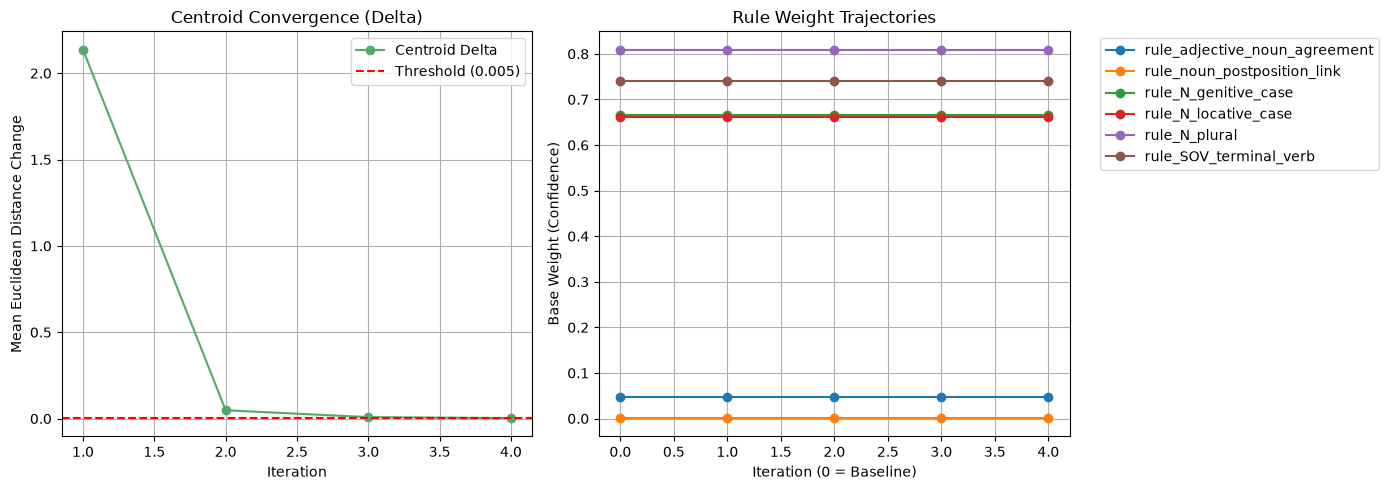

In [23]:
# Plot convergence and rule weights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Centroid convergence
ax1.plot(range(1, len(centroid_history) + 1), centroid_history, marker="o", color="#55A868", label="Centroid Delta")
ax1.axhline(delta_threshold, color="red", linestyle="--", label="Threshold (0.005)")
ax1.set_title("Centroid Convergence (Delta)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Mean Euclidean Distance Change")
ax1.legend()
ax1.grid(True)

# 2. Rule weights trajectory
rules_to_plot = ["rule_adjective_noun_agreement", "rule_noun_postposition_link", "rule_N_genitive_case", "rule_N_locative_case", "rule_N_plural", "rule_SOV_terminal_verb"]
for rid in rules_to_plot:
    if rid in rule_weight_history:
        ax2.plot(range(len(rule_weight_history[rid])), rule_weight_history[rid], marker="o", label=rid)
ax2.set_title("Rule Weight Trajectories")
ax2.set_xlabel("Iteration (0 = Baseline)")
ax2.set_ylabel("Base Weight (Confidence)")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [24]:
# Comparison of initial and final performance on the held-out test set
baseline_test_acc = init_test_acc
final_test_acc = test_accuracy_history[-1]

compare_df = pd.DataFrame([
    {"metric": "Baseline (Before EM)", "test_accuracy": f"{baseline_test_acc*100:.2f}%"},
    {"metric": "Final (After EM Loop)", "test_accuracy": f"{final_test_acc*100:.2f}%"}
])
display(compare_df)


,metric,test_accuracy
0,Baseline (Before EM),64.38%
1,Final (After EM Loop),62.77%


## Phase 6 — Rule Refinement & Extended EM Loop

Analysis of the confusion matrix (Phase 2) reveals the **"Noun Magnet"** problem:
the `-ৰ` (genitive) and `-ত` (locative) suffix rules fire aggressively on
short words that are actually Adjectives or Verbs.

Three targeted fixes applied to `grammar_rules.json`:

1. **`min_root_length: 3`** on `rule_N_genitive_case` and `rule_N_locative_case`:
   prevents the Noun rules from firing when the root (word minus suffix) is
   shorter than 3 characters — those short forms are typically pronouns or adjectives.
2. **`min_root_length: 3`** on `rule_Adv_formation` (`কৈ`, `ভাৱে`): stops the
   adverb rule from misfiring on short words and bleeding into the Adj category.
3. **New `rule_Adj_quality_suffix`**: covers productive Assamese adjective-forming
   suffixes (`ীয়া`, `ীয়`, `িক`, `কাৰী`, `শীল`, `ময়`, `বান`, `বতী`, `ৱান`) to boost Adjective recall.

The `RuleEngine._pass1()` method (Cell 9) has been extended to honor the
`min_root_length` field per-rule in the JSON.

The EM loop is then re-run for a **forced 15 iterations** (ignoring the
convergence delta threshold) to allow the model to settle into a better
global optimum with the improved rule set.

[Phase 6 Rule Engine — After Refinement]
Seed tokens scored:     8734
Rule firing coverage:   46.2%
Precision when firing:  64.9%
Overall accuracy:       30.0%



,rule_predicted,actual,count
0,Adj,N,315
1,N,Adj,219
2,PREP,N,207
3,V,N,136
4,PREP,Adj,87
5,N,V,69
6,N,Pr,62
7,Adj,V,58
8,V,Adj,42
9,Adv,Adj,32


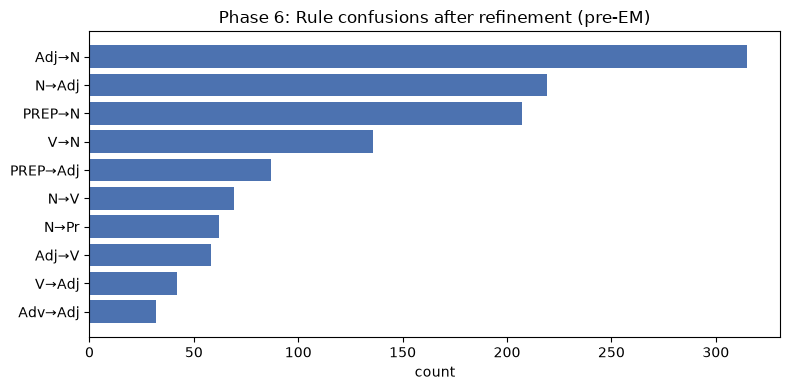

In [25]:
# ── Phase 6: Reload refined engine and evaluate seed set ──
engine = RuleEngine("rules/grammar_rules.json")

correct6_pre = fired6_pre = total6_pre = 0
confusions6 = {}
for sent in split.seed:
    hyps = engine.evaluate_sentence(sent)
    for tok, hyp in zip(sent, hyps):
        if tok.gold_tag is None:
            continue
        total6_pre += 1
        if hyp.tag is not None:
            fired6_pre += 1
            if hyp.tag == tok.gold_tag:
                correct6_pre += 1
            else:
                confusions6[(hyp.tag, tok.gold_tag)] = confusions6.get((hyp.tag, tok.gold_tag), 0) + 1

print("[Phase 6 Rule Engine — After Refinement]")
print(f"Seed tokens scored:     {total6_pre}")
print(f"Rule firing coverage:   {100*fired6_pre/total6_pre:.1f}%")
print(f"Precision when firing:  {100*correct6_pre/fired6_pre:.1f}%")
print(f"Overall accuracy:       {100*correct6_pre/total6_pre:.1f}%")
print()

conf6_df = pd.DataFrame(
    [(pred, actual, cnt) for (pred, actual), cnt in sorted(confusions6.items(), key=lambda kv: -kv[1])[:10]],
    columns=["rule_predicted", "actual", "count"]
)
display(conf6_df)

fig, ax = plt.subplots(figsize=(8, 4))
labels6_pre = [f"{r.rule_predicted}→{r.actual}" for r in conf6_df.itertuples()]
ax.barh(labels6_pre[::-1], conf6_df["count"][::-1], color="#4C72B0")
ax.set_title("Phase 6: Rule confusions after refinement (pre-EM)")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()


In [26]:
# ── Phase 6: Reset pseudo-labels and run forced 15-iteration EM ──
import copy
from collections import Counter

# Reset all pseudo-labels on the unlabeled pool
for sent in split.unlabeled_pool:
    for tok in sent:
        tok.tag = None

# Re-sort curriculum by anchor ratio with updated rules
active_ratios6 = []
for idx in active_indices:
    sent = split.unlabeled_pool[idx]
    hyps = engine.evaluate_sentence(sent)
    ratio = sum(1 for h in hyps if h.tag is not None) / len(sent) if len(sent) > 0 else 0.0
    active_ratios6.append((idx, ratio))
sorted_active6 = [idx for idx, _ in sorted(active_ratios6, key=lambda x: x[1], reverse=True)]

ref_map6 = {(s_idx, pos): i for i, (s_idx, pos) in enumerate(fit_refs)}

MAX_ITERS_6 = 15
delta_history6, test_acc_history6 = [], []
rule_weight_history6 = {rid: [engine.rules_by_id[rid]["base_weight"]] for rid in engine.rules_by_id}

print(f"Starting Phase 6 Extended EM (forced {MAX_ITERS_6} iterations)...\n")

for iteration in range(1, MAX_ITERS_6 + 1):
    new_pseudo_labels = 0
    retraction_counts = Counter()
    arbitrator6 = VectorArbitrator(vmodel)

    for u_idx in sorted_active6:
        sent = split.unlabeled_pool[u_idx]
        s_idx = len(split.seed) + u_idx
        rule_hyps = engine.evaluate_sentence(sent)
        for pos, tok in enumerate(sent):
            if tok.tag is not None:
                continue
            rule_hyp = rule_hyps[pos]
            feat_idx = ref_map6.get((s_idx, pos))
            if feat_idx is None:
                continue
            raw_v = fit_raw[feat_idx]
            red_v = fit_reduced[feat_idx]
            result = arbitrate_token(
                tok.word, rule_hyp, lexicon.get(tok.word), raw_v, red_v,
                arbitrator6, engine,
                conflict_threshold=best_conflict_threshold,
                min_vector_confidence=best_min_vector_confidence
            )
            if result.rule_retracted:
                retraction_counts[result.rule_retracted] += 1
            if result.final_tag is not None:
                score = result.c_final.get(result.final_tag, 0.0)
                if score >= best_tau_high:
                    tok.tag = result.final_tag
                    new_pseudo_labels += 1

    old_prototypes = copy.deepcopy(vmodel.dense_prototypes)
    expanded_raw6, expanded_reduced6, tags6 = get_expanded_corpus_features(
        split, val_indices, fit_raw, fit_reduced, fit_refs
    )
    vmodel.fit_prototypes(expanded_raw6, expanded_reduced6, tags6)

    distances = [np.linalg.norm(vmodel.dense_prototypes[t] - old_prototypes[t])
                 for t in vmodel.dense_prototypes if t in old_prototypes]
    delta = np.mean(distances) if distances else 0.0
    delta_history6.append(delta)

    for rid in engine.rules_by_id:
        penalty = 0.001 * retraction_counts.get(rid, 0)
        engine.apply_evolution_update(rid, weight_penalty=penalty)
        rule_weight_history6[rid].append(engine.rules_by_id[rid]["base_weight"])

    test_acc = evaluate_test_set(best_conflict_threshold, best_min_vector_confidence)
    test_acc_history6.append(test_acc)

    total_pl = sum(1 for idx in sorted_active6 for tok in split.unlabeled_pool[idx] if tok.tag is not None)
    print(f"Iter {iteration:2d}: Δ={delta:.4f} | new_labels={new_pseudo_labels:5d} | total_pl={total_pl:6d} | test_acc={test_acc*100:.2f}%")

# Persist evolved rules
with open("rules/grammar_rules.json", "r", encoding="utf-8") as f:
    rules_disk = json.load(f)
rules_disk["rules"] = list(engine.rules_by_id.values())
with open("rules/grammar_rules.json", "w", encoding="utf-8") as f:
    json.dump(rules_disk, f, ensure_ascii=False, indent=2)
print("\nPhase 6 EM complete! Evolved rules persisted to grammar_rules.json.")


Starting Phase 6 Extended EM (forced 15 iterations)...

Iter  1: Δ=0.0656 | new_labels= 8052 | total_pl=  8052 | test_acc=63.31%
Iter  2: Δ=0.0361 | new_labels=  569 | total_pl=  8621 | test_acc=63.06%
Iter  3: Δ=0.0047 | new_labels=   33 | total_pl=  8654 | test_acc=63.18%
Iter  4: Δ=0.0026 | new_labels=   15 | total_pl=  8669 | test_acc=63.18%
Iter  5: Δ=0.0018 | new_labels=   14 | total_pl=  8683 | test_acc=63.20%
Iter  6: Δ=0.0007 | new_labels=    5 | total_pl=  8688 | test_acc=63.22%
Iter  7: Δ=0.0004 | new_labels=    3 | total_pl=  8691 | test_acc=63.22%
Iter  8: Δ=0.0003 | new_labels=    1 | total_pl=  8692 | test_acc=63.25%
Iter  9: Δ=0.0000 | new_labels=    0 | total_pl=  8692 | test_acc=63.25%
Iter 10: Δ=0.0000 | new_labels=    0 | total_pl=  8692 | test_acc=63.25%
Iter 11: Δ=0.0000 | new_labels=    0 | total_pl=  8692 | test_acc=63.25%
Iter 12: Δ=0.0000 | new_labels=    0 | total_pl=  8692 | test_acc=63.25%
Iter 13: Δ=0.0000 | new_labels=    0 | total_pl=  8692 | test_acc=63

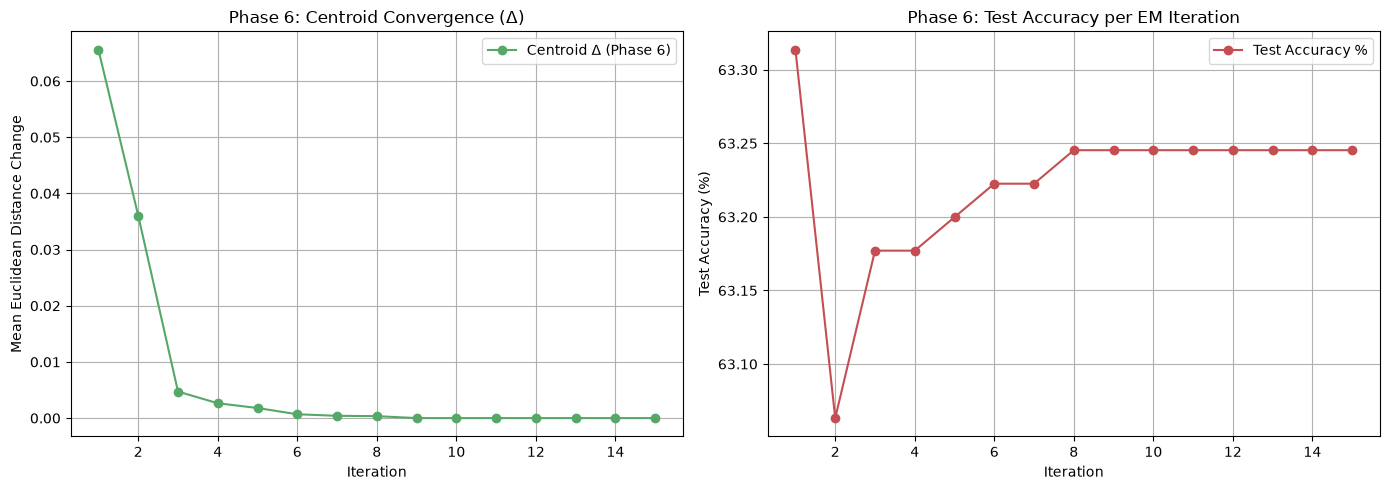

In [27]:
# ── Phase 6: Convergence + accuracy plots ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(delta_history6)+1), delta_history6,
         marker="o", color="#55A868", label="Centroid Δ (Phase 6)")
ax1.set_title("Phase 6: Centroid Convergence (Δ)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Mean Euclidean Distance Change")
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, len(test_acc_history6)+1), [a*100 for a in test_acc_history6],
         marker="o", color="#C44E52", label="Test Accuracy %")
ax2.set_title("Phase 6: Test Accuracy per EM Iteration")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Test Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [28]:
# ── Phase 6: Final comparison table ──
compare6_df = pd.DataFrame([
    {"Phase": "Baseline (before EM)",           "Test Accuracy": f"{init_test_acc*100:.2f}%"},
    {"Phase": "Phase 5 (4-iter EM)",              "Test Accuracy": f"{test_accuracy_history[-1]*100:.2f}%"},
    {"Phase": "Phase 6 (15-iter + rule fixes)",   "Test Accuracy": f"{test_acc_history6[-1]*100:.2f}%"},
])
display(compare6_df)


,Phase,Test Accuracy
0,Baseline (before EM),64.38%
1,Phase 5 (4-iter EM),62.77%
2,Phase 6 (15-iter + rule fixes),63.25%


In [29]:
from sklearn.metrics import classification_report, v_measure_score

# Extract test set data
test_raw, test_refs = encoder.encode_corpus(split.held_out_test)
test_reduced = vmodel.transform(test_raw)

y_true = []
y_pred = []

# Perform inference on the held-out test set
for i, (s_idx, pos) in enumerate(test_refs):
    tok = split.held_out_test[s_idx][pos]
    if tok.gold_tag is None: continue
    
    rule_hyps = engine.evaluate_sentence(split.held_out_test[s_idx])
    result = arbitrate_token(tok.word, rule_hyps[pos], lexicon.get(tok.word), 
                             test_raw[i], test_reduced[i], arbitrator, engine)
    
    y_true.append(tok.gold_tag)
    y_pred.append(result.final_tag if result.final_tag else "None")

# Output metrics
print("--- Classification Report ---")
print(classification_report(y_true, y_pred, zero_division=0))
print(f"V-Measure Score: {v_measure_score(y_true, y_pred):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

         Adj       0.85      0.46      0.60       855
         Adv       0.08      0.47      0.14        70
         CON       0.90      0.86      0.88       243
          IN       0.00      1.00      0.00         1
           N       0.80      0.60      0.69      2038
        PREP       0.48      0.65      0.55        83
          Pr       0.92      0.63      0.75       299
           V       0.73      0.83      0.78       805

    accuracy                           0.63      4394
   macro avg       0.60      0.69      0.55      4394
weighted avg       0.79      0.63      0.69      4394

V-Measure Score: 0.3979
